**TEXT SIMILARITY USING COSINE SIMILARITY**

---



Cosine similarity is a metric used to determine the cosine angle between two non-zero vectors in a multi-dimensional space .

Basicly ,it's a measure of how similar the ideas and concepts represented in two pieces of text are.



Mathematical definition :  It’s calculated as the dot product of two vectors divided by the product of their magnitudes.

*   In the context of text similarity, this metric provides a robust way to gauge the similarity between two sets of text data.

*   A smaller distance indicates a higher similarity, while a larger distance indicates a lower similarity.

*    It is widely used in machine learning and text analysis, document comparison, search queries, and recommendation systems.



**In theory , how cosine similarity is represented**

1.   Close to 1 if the vectors point in the same direction (indicating high similarity)

2.   Close to -1 if the vectors point in opposite directions (indicating high dissimilarity)

3.  Close to 0 if the vectors are orthogonal (indicating unrelatedness)



In text similarity , we find how far the given text shares similar ideas and concepts .
> Break down in simple steps :



1.   Tokenize the text data
2.   Do text pre-processing such as remove stopwords ,punctuations etc
3.   Now , convert the processed data into vector form. Can use tfidf -term frequence and inverse document frequence.
4.   Pass the vectors to cosine similarity function



In [1]:
# importing the libraries

import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [2]:
# load the data

doc1 = "Natural Language Processing (NLP) is a branch of artificial intelligence that enables computers to understand, interpret, and generate human language. By combining computational linguistics with machine learning and deep learning models,NLP bridges the gap between human communication and machine understanding"
doc2 = "Modern NLP relies heavily on machine learning to automatically learn grammar, context, and meaning from large text datasets rather than using manually coded rules"
doc3 = "Artificial intelligence (AI) is a branch of computer science focused on building systems capable of performing tasks that typically require human intelligence"
doc4 = "I love fruits ."

# all the docs in variabe for looping the process
documents = [doc1 ,doc2 , doc3]

# to store
stop_word = stopwords.words("english")
punctuation = list(string.punctuation)


In [3]:
# text pre-processing

def pre_processing(text):
  # converting the input data into tokens
  tokens = word_tokenize(text.lower())

  # checking for stopwords and punctuations
  clean_tokens = [token for token in tokens
                  if token not in stop_word and
                  token not in punctuation]
  # return
  return " ".join(clean_tokens)

# appling to data
processed_data = [pre_processing(docs) for docs in documents]

In [4]:
processed_data

['natural language processing nlp branch artificial intelligence enables computers understand interpret generate human language combining computational linguistics machine learning deep learning models nlp bridges gap human communication machine understanding',
 'modern nlp relies heavily machine learning automatically learn grammar context meaning large text datasets rather using manually coded rules',
 'artificial intelligence ai branch computer science focused building systems capable performing tasks typically require human intelligence']

In [5]:
# vectorizer
vectorizer = TfidfVectorizer()

# converting the data into vector format
vectors = vectorizer.fit_transform(processed_data)

In [6]:
# similarity check
cosine_simi = cosine_similarity(vectors)
print(" Cosine Similarity fpr the given docs are : ")
for row in cosine_simi:
  print(row)

 Cosine Similarity fpr the given docs are : 
[1.         0.14803118 0.16070165]
[0.14803118 1.         0.        ]
[0.16070165 0.         1.        ]


Text(0.5, 1.0, 'Text Similarity Heatmap')

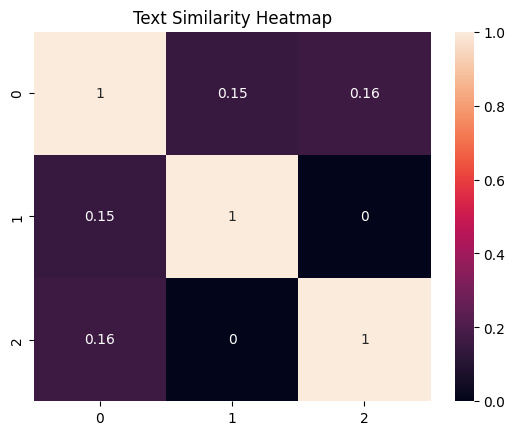

In [7]:
sns.heatmap(cosine_simi,annot=True)
plt.title("Text Similarity Heatmap")

**Conclusion:**
The text similarity heatmap shown above illustrates the similarity scores between the documents. Documents 2 and 3 have a similarity score of **0.00**, indicating that they share no common textual content. The remaining document pairs have similarity scores of approximately **0.16** and **0.15**, which represent a low level of similarity.

Although the topics or concepts in the given texts may be interconnected, the specific words and phrases are not present across the documents. As a result, the similarity scores remain low, and Documents 2 and 3 show no similarity at all.
